<a href="https://colab.research.google.com/github/ndvphuc07/HW/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
pip install scikit-fuzzy


Price: 92.22222222222223
Reward: 22.630618116876676


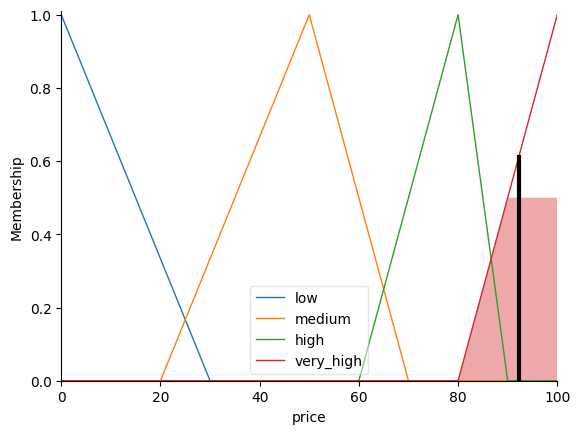

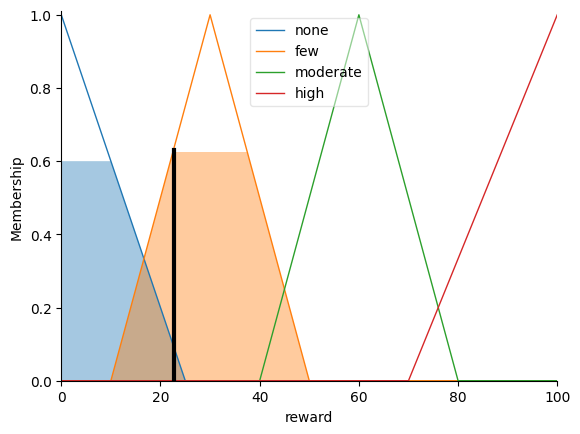

In [75]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input
distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 100.1, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 100.1, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 10.1, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 100.1, 1), 'punctuality')

# Output
price = ctrl.Consequent(np.arange(0, 100.1, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 100.1, 1), 'reward')
# Distance
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 12, 20])
distance['very_long'] = fuzz.trimf(distance.universe, [15, 30, 50])

# Traffic (%)
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

# Demand (%)
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

# Weather (encode: 0=bad, 5=moderate, 10=good)
weather['bad'] = fuzz.trimf(weather.universe, [0, 0, 5])
weather['moderate'] = fuzz.trimf(weather.universe, [0, 5, 10])
weather['good'] = fuzz.trimf(weather.universe, [5, 10, 10])

# Rating
rating['poor'] = fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2, 3, 4])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 5, 5])

# Punctuality
punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

# Price
price['low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['medium'] = fuzz.trimf(price.universe, [20, 50, 70])
price['high'] = fuzz.trimf(price.universe, [60, 80, 90])
price['very_high'] = fuzz.trimf(price.universe, [80, 100, 100])

# Reward
reward['none'] = fuzz.trimf(reward.universe, [0, 0, 25])
reward['few'] = fuzz.trimf(reward.universe, [10, 30, 50])
reward['moderate'] = fuzz.trimf(reward.universe, [40, 60, 80])
reward['high'] = fuzz.trimf(reward.universe, [70, 100, 100])

rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])
rule11 = ctrl.Rule(rating['good'] & punctuality['early'], reward['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate'])
rule16 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule17 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high'])
rule18 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few'])
rule19 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few'])
rule20 = ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
rule_default_reward = ctrl.Rule(
    distance['short'] | distance['medium'] | distance['long'] | distance['very_long'],
    reward['few']
)

system_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5,
    rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15,
    rule16, rule17, rule18, rule19, rule20,
    rule_default_reward
])
system = ctrl.ControlSystemSimulation(system_ctrl)

system.input['distance'] = 15
system.input['traffic'] = 80
system.input['demand'] = 30
system.input['weather'] = 2
system.input['rating'] = 1.5
system.input['punctuality'] = 20

system.compute()

print("Price:", system.output['price'])
print("Reward:", system.output['reward'])

# Visualize
price.view(sim=system)
reward.view(sim=system)

Mức chiết khấu đề xuất: 38.05555555555555 %


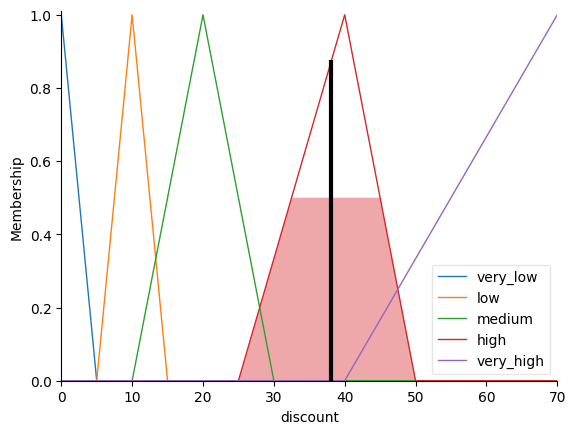

In [76]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(0,5.1,0.1),'rating')
sales = ctrl.Antecedent(np.arange(0,101,1),'sales')
profit = ctrl.Antecedent(np.arange(0,51,1),'profit')
season = ctrl.Antecedent(np.arange(0,11,1),'season')
competitor = ctrl.Antecedent(np.arange(0,51,1),'competitor')
discount = ctrl.Consequent(np.arange(0,71,1),'discount')

# Rating
rating['low'] = fuzz.trimf(rating.universe,[0,0,4])
rating['medium'] = fuzz.trimf(rating.universe,[3.8,4.3,4.6])
rating['high'] = fuzz.trimf(rating.universe,[4.5,5,5])

# Sales
sales['low'] = fuzz.trimf(sales.universe,[0,0,40])
sales['medium'] = fuzz.trimf(sales.universe,[30,50,70])
sales['high'] = fuzz.trimf(sales.universe,[60,100,100])

# Profit
profit['low'] = fuzz.trimf(profit.universe,[0,0,20])
profit['medium'] = fuzz.trimf(profit.universe,[15,30,40])
profit['high'] = fuzz.trimf(profit.universe,[35,50,50])

# Season
season['none'] = fuzz.trimf(season.universe,[0,0,3])
season['moderate'] = fuzz.trimf(season.universe,[2,5,7])
season['high'] = fuzz.trimf(season.universe,[6,10,10])

# Competitor
competitor['low'] = fuzz.trimf(competitor.universe,[0,0,15])
competitor['medium'] = fuzz.trimf(competitor.universe,[10,25,35])
competitor['high'] = fuzz.trimf(competitor.universe,[30,50,50])

# Discount (output)
discount['very_low'] = fuzz.trimf(discount.universe,[0,0,5])
discount['low'] = fuzz.trimf(discount.universe,[5,10,15])
discount['medium'] = fuzz.trimf(discount.universe,[10,20,30])
discount['high'] = fuzz.trimf(discount.universe,[25,40,50])
discount['very_high'] = fuzz.trimf(discount.universe,[40,70,70])

rule1 = ctrl.Rule(rating['high'] & sales['high'] & profit['high'],
                  discount['very_low'])

rule2 = ctrl.Rule(rating['low'] & sales['low'] & profit['high'],
                  discount['high'])

rule3 = ctrl.Rule(season['high'] & competitor['high'],
                  discount['high'])

rule4 = ctrl.Rule(rating['medium'] & sales['medium'] & profit['medium'],
                  discount['medium'])

rule5 = ctrl.Rule(competitor['low'] & profit['low'] & sales['high'],
                  discount['very_low'])

rule6 = ctrl.Rule(rating['low'] & season['none'],
                  discount['medium'])

rule7 = ctrl.Rule(sales['low'] & profit['low'],
                  discount['very_high'])

discount_ctrl = ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,rule6,rule7
])

discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['rating'] = 4.3
discount_sim.input['sales'] = 50
discount_sim.input['profit'] = 15
discount_sim.input['season'] = 9
discount_sim.input['competitor'] = 40

discount_sim.compute()

print("Mức chiết khấu đề xuất:", discount_sim.output['discount'], "%")

discount.view(sim=discount_sim)

Discount đề xuất: 19.99999999999996


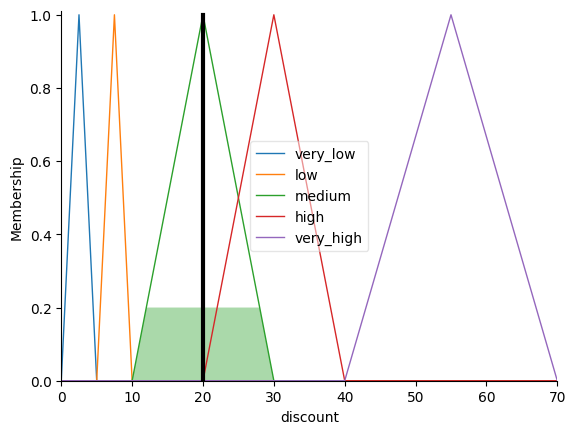

In [77]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input (0-10)
demand = ctrl.Antecedent(np.arange(0,10.1,0.1),'demand')
competition = ctrl.Antecedent(np.arange(0,10.1,0.1),'competition')
reputation = ctrl.Antecedent(np.arange(0,10.1,0.1),'reputation')
profit = ctrl.Antecedent(np.arange(0,10.1,0.1),'profit')
season = ctrl.Antecedent(np.arange(0,10.1,0.1),'season')

# Output (Discount %)
discount = ctrl.Consequent(np.arange(0,70.1,0.1),'discount')

# Demand
demand['low'] = fuzz.trimf(demand.universe,[0,0,5])
demand['medium'] = fuzz.trimf(demand.universe,[0,5,10])
demand['high'] = fuzz.trimf(demand.universe,[5,10,10])

# Competition
competition['low'] = fuzz.trimf(competition.universe,[0,0,5])
competition['medium'] = fuzz.trimf(competition.universe,[0,5,10])
competition['high'] = fuzz.trimf(competition.universe,[5,10,10])

# Reputation
reputation['low'] = fuzz.trimf(reputation.universe,[0,0,5])
reputation['medium'] = fuzz.trimf(reputation.universe,[0,5,10])
reputation['high'] = fuzz.trimf(reputation.universe,[5,10,10])

# Profit
profit['low'] = fuzz.trimf(profit.universe,[0,0,5])
profit['medium'] = fuzz.trimf(profit.universe,[0,5,10])
profit['high'] = fuzz.trimf(profit.universe,[5,10,10])

# Season
season['low'] = fuzz.trimf(season.universe,[0,0,5])   # Không có
season['medium'] = fuzz.trimf(season.universe,[0,5,10])
season['high'] = fuzz.trimf(season.universe,[5,10,10])

# Discount (%)
discount['very_low'] = fuzz.trimf(discount.universe,[0,2.5,5])
discount['low'] = fuzz.trimf(discount.universe,[5,7.5,10])
discount['medium'] = fuzz.trimf(discount.universe,[10,20,30])
discount['high'] = fuzz.trimf(discount.universe,[20,30,40])
discount['very_high'] = fuzz.trimf(discount.universe,[40,55,70])

rule1 = ctrl.Rule(demand['high'] & competition['low'] & profit['low'], discount['very_low'])

rule2 = ctrl.Rule(demand['low'] & competition['high'] & profit['high'], discount['high'])

rule3 = ctrl.Rule(reputation['high'] & profit['medium'] & season['high'], discount['medium'])

rule4 = ctrl.Rule(competition['high'] & season['high'] & profit['high'], discount['very_high'])

rule5 = ctrl.Rule(reputation['low'] & demand['medium'] & profit['low'], discount['medium'])

rule6 = ctrl.Rule(demand['high'] & season['low'] & competition['low'], discount['very_low'])

rule7 = ctrl.Rule(profit['high'] & competition['medium'] & season['medium'], discount['medium'])

discount_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7
])

discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

# Đồng hồ xa xỉ thủ công
discount_sim.input['demand'] = 9        # Cao
discount_sim.input['competition'] = 5   # Trung bình
discount_sim.input['reputation'] = 5    # Trung bình
discount_sim.input['profit'] = 9        # Cao
discount_sim.input['season'] = 9        # Cao

discount_sim.compute()

print("Discount đề xuất:", discount_sim.output['discount'])

# Vẽ kết quả
discount.view(sim=discount_sim)

Số đơn nên ghép: 5.000000000000001
Độ ưu tiên giao hàng: 5.0


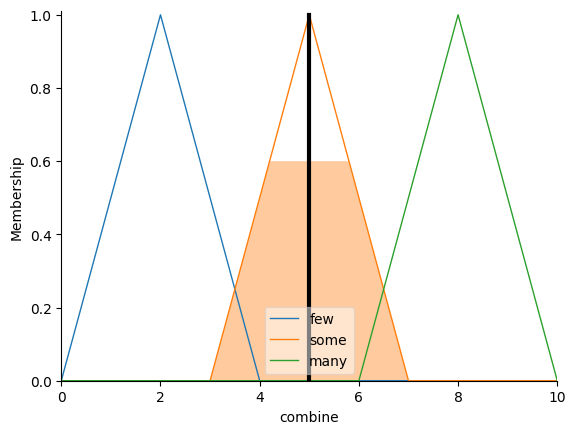

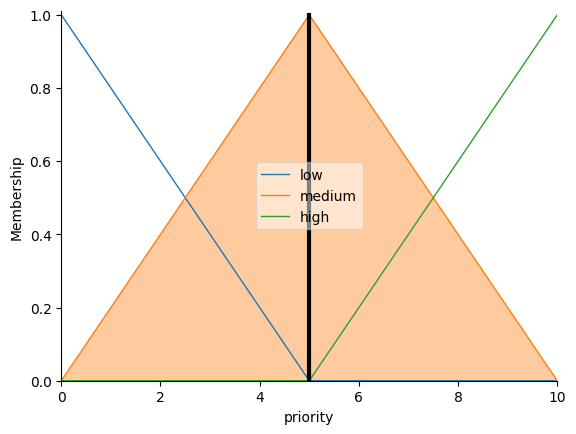

In [79]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0,10.1,0.1),'density')
urgency = ctrl.Antecedent(np.arange(0,10.1,0.1),'urgency')
load = ctrl.Antecedent(np.arange(0,10.1,0.1),'load')
traffic = ctrl.Antecedent(np.arange(0,10.1,0.1),'traffic')
profit = ctrl.Antecedent(np.arange(0,10.1,0.1),'profit')

combine = ctrl.Consequent(np.arange(0,10.1,0.1),'combine')
priority = ctrl.Consequent(np.arange(0,10.1,0.1),'priority')

def three_level(var):
    var['low'] = fuzz.trimf(var.universe,[0,0,5])
    var['medium'] = fuzz.trimf(var.universe,[0,5,10])
    var['high'] = fuzz.trimf(var.universe,[5,10,10])

for v in [density, urgency, load, traffic, profit]:
    three_level(v)

# Output: combine
combine['few'] = fuzz.trimf(combine.universe,[0,2,4])
combine['some'] = fuzz.trimf(combine.universe,[3,5,7])
combine['many'] = fuzz.trimf(combine.universe,[6,8,10])

# Output: priority
priority['low'] = fuzz.trimf(priority.universe,[0,0,5])
priority['medium'] = fuzz.trimf(priority.universe,[0,5,10])
priority['high'] = fuzz.trimf(priority.universe,[5,10,10])

r1 = ctrl.Rule(density['high'] & load['low'] & traffic['low'], combine['many'])

r2 = ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine['some'])

r3 = ctrl.Rule(load['high'] & density['high'] & profit['medium'], combine['some'])

r4 = ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['some'])

r5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['some'])

r6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])

r7 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])

r8 = ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])

r_fix = ctrl.Rule(density['high'] & load['low'], combine['some'])

system = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r_fix])
sim = ctrl.ControlSystemSimulation(system)

sim.input['density'] = 9     # cao
sim.input['urgency'] = 5   # trung bình
sim.input['load'] = 2        # thấp
sim.input['traffic'] = 5     # trung bình
sim.input['profit'] = 5      # trung bình

sim.compute()

print("Số đơn nên ghép:", sim.output['combine'])
print("Độ ưu tiên giao hàng:", sim.output['priority'])

# visualize
combine.view(sim=sim)
priority.view(sim=sim)

Số đơn nên ghép: 5.000000000000001
Độ ưu tiên: 5.0


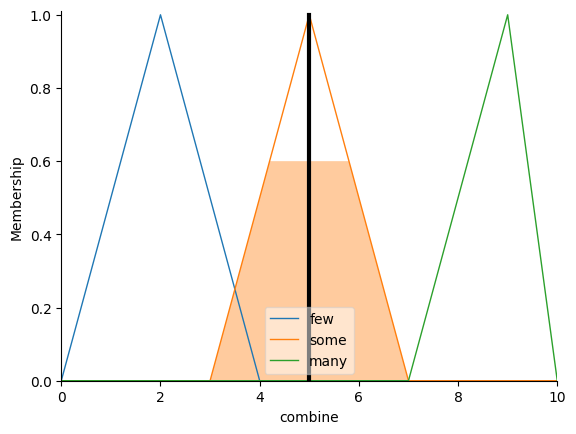

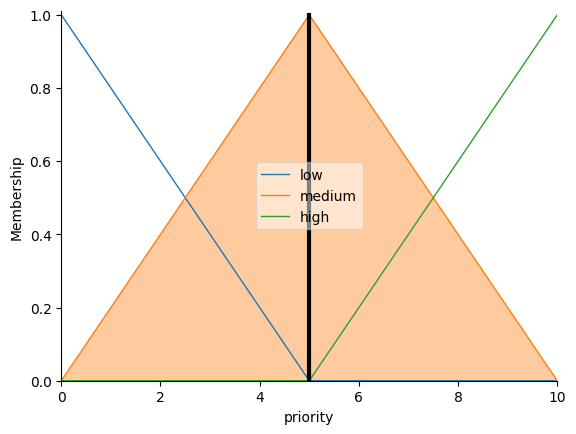

In [78]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0,10.1,0.1),'density')
urgency = ctrl.Antecedent(np.arange(0,10.1,0.1),'urgency')
load = ctrl.Antecedent(np.arange(0,10.1,0.1),'load')
traffic = ctrl.Antecedent(np.arange(0,10.1,0.1),'traffic')
profit = ctrl.Antecedent(np.arange(0,10.1,0.1),'profit')

combine = ctrl.Consequent(np.arange(0,10.1,0.1),'combine')
priority = ctrl.Consequent(np.arange(0,10.1,0.1),'priority')

def three(var):
    var['low'] = fuzz.trimf(var.universe,[0,0,5])
    var['medium'] = fuzz.trimf(var.universe,[0,5,10])
    var['high'] = fuzz.trimf(var.universe,[5,10,10])

for v in [density, urgency, load, traffic, profit]:
    three(v)

# Output combine
combine['few'] = fuzz.trimf(combine.universe,[0,2,4])
combine['some'] = fuzz.trimf(combine.universe,[3,5,7])
combine['many'] = fuzz.trimf(combine.universe,[7,9,10])

# Output priority
priority['low'] = fuzz.trimf(priority.universe,[0,0,5])
priority['medium'] = fuzz.trimf(priority.universe,[0,5,10])
priority['high'] = fuzz.trimf(priority.universe,[5,10,10])

r1 = ctrl.Rule(density['high'] & load['low'] & traffic['low'], combine['many'])

r2 = ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine['some'])

r3 = ctrl.Rule(load['high'] & density['high'] & profit['medium'], combine['some'])

r4 = ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['some'])

r5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['some'])

r6 = ctrl.Rule(density['high'] & load['low'] & traffic['medium'], combine['some'])

r7 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])

r8 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])

r9 = ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])

r10 = ctrl.Rule(traffic['high'] & density['medium'], combine['few'])

r11 = ctrl.Rule(load['low'] & urgency['low'], combine['many'])

r12 = ctrl.Rule(traffic['high'] & urgency['low'], priority['low'])

r13 = ctrl.Rule(traffic['low'] & urgency['high'], priority['high'])

system = ctrl.ControlSystem([
    r1,r2,r3,r4,r5,r6,
    r7,r8,r9,
    r10,r11,r12,r13
])

sim = ctrl.ControlSystemSimulation(system)

sim.input['density'] = 9     # cao
sim.input['urgency'] = 5     # trung bình
sim.input['load'] = 2        # thấp
sim.input['traffic'] = 5     # trung bình
sim.input['profit'] = 5      # trung bình

sim.compute()

print("Số đơn nên ghép:", sim.output['combine'])
print("Độ ưu tiên:", sim.output['priority'])

combine.view(sim=sim)
priority.view(sim=sim)